In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OrdinalEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import category_encoders as ce
from sklearn.neighbors import NearestNeighbors
import joblib
warnings.filterwarnings('ignore')

In [4]:
df= pd.read_csv(r"D:\ML Projects\UAE Real Estate\data\uae_real_estate_2024.csv")
df.head()

,title,displayAddress,bathrooms,bedrooms,addedOn,type,price,verified,priceDuration,sizeMin,furnishing,description
0,Great ROI I High Floor I Creek View,"Binghatti Canal, Business Bay, Dubai",3,2,2024-08-14T12:02:53Z,Residential for Sale,2500000,True,sell,1323 sqft,NO,MNA Properties is delighted to offer this apar...
1,Full Sea View | Beach Life | Brand New Residence,"La Vie, Jumeirah Beach Residence, Dubai",3,2,2024-08-13T05:45:16Z,Residential for Sale,7200000,True,sell,1410 sqft,YES,"Apartment for sale in La Vie, Jumeirah Beach R..."
2,Green Belt | Corner Unit | Spacious Plot,"La Rosa 6, Villanova, Dubai Land, Dubai",3,4,2024-08-14T06:24:28Z,Residential for Sale,3600000,True,sell,2324 sqft,NO,Treo Homes is very pleased to be bringing to t...
3,2BR+Study | Near Pool and Park | Private,"Springs 15, The Springs, Dubai",3,2,2024-08-15T06:07:22Z,Residential for Sale,2999999,True,sell,1647 sqft,NO,2 Bedrooms + Study | Near Pool &amp; Park | Pr...
4,Vacant | Well Maintained | Area Expert,"Noor Townhouses, Town Square, Dubai",3,3,2024-08-09T08:28:59Z,Residential for Sale,2449999,True,sell,2105 sqft,NO,-Type 1\n-3 Bed+Maid\n-Close To Amenities\n-BU...


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5058 entries, 0 to 5057
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   title           5058 non-null   str  
 1   displayAddress  5058 non-null   str  
 2   bathrooms       4938 non-null   str  
 3   bedrooms        4935 non-null   str  
 4   addedOn         5058 non-null   str  
 5   type            5058 non-null   str  
 6   price           5058 non-null   int64
 7   verified        5058 non-null   bool 
 8   priceDuration   5058 non-null   str  
 9   sizeMin         5058 non-null   str  
 10  furnishing      5056 non-null   str  
 11  description     5057 non-null   str  
dtypes: bool(1), int64(1), str(10)
memory usage: 7.4 MB


In [6]:
df.shape

(5058, 12)

In [7]:
df.isna().sum()

title               0
displayAddress      0
bathrooms         120
bedrooms          123
addedOn             0
type                0
price               0
verified            0
priceDuration       0
sizeMin             0
furnishing          2
description         1
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df['sizeMin'].unique()

<ArrowStringArray>
[ '1323 sqft',  '1410 sqft',  '2324 sqft',  '1647 sqft',  '2105 sqft',
  '7059 sqft',  '1095 sqft',  '1991 sqft',  '1881 sqft',   '669 sqft',
 ...
  '2935 sqft',   '379 sqft',  '2094 sqft', '10539 sqft',  '3449 sqft',
  '1942 sqft',  '1674 sqft',  '5239 sqft',  '4505 sqft',  '3813 sqft']
Length: 2516, dtype: str

# Data Cleaning & Feature Extraction

In [10]:
# Clean sizeMin: remove 'sqft' and convert to float
df['sizeMin'] = df['sizeMin'].str.replace(' sqft', '').astype(float)
df.rename(columns={'sizeMin': 'sizeMin_sqft'}, inplace=True)

In [11]:
# Rename displayAddress
df.rename(columns={'displayAddress': 'address'}, inplace=True)

In [12]:
print(df['bedrooms'].unique())
print(df['bathrooms'].unique())

<ArrowStringArray>
['2', '4', '3', '5', '1', 'studio', nan, '7', '6', '7+']
Length: 10, dtype: str
<ArrowStringArray>
['3', '7', '4', '1', '5', '2', '6', nan, '7+', 'none']
Length: 10, dtype: str


In [13]:
# Bedrooms: convert 'Studio' to 0 BEFORE converting to numeric to avoid Data Loss
df['bedrooms'] = df['bedrooms'].astype(str).str.lower().replace('studio', '0')
df['bedrooms'] = df['bedrooms'].str.extract(r'(\d+)').astype(float)

# Bathrooms: extract float (e.g., '3+' becomes 3.0)
df['bathrooms'] = df['bathrooms'].astype(str).str.extract(r'(\d+)').astype(float)

In [14]:
# Extract the second-to-last element (The Main Community)
def extract_community(address):
    parts = str(address).split(',')
    if len(parts) >= 2:
        return parts[-2].strip()
    return str(address).strip()

df['community'] = df['address'].apply(extract_community)

In [15]:
cols= ['verified', 'priceDuration', 'type', 'furnishing']
for col in cols:
    print(f"Value counts for {col}:")
    print(df[col].value_counts())
    print("\n")

Value counts for verified:
verified
True     3271
False    1787
Name: count, dtype: int64


Value counts for priceDuration:
priceDuration
sell    5058
Name: count, dtype: int64


Value counts for type:
type
Residential for Sale    5058
Name: count, dtype: int64


Value counts for furnishing:
furnishing
NO        3630
YES       1015
PARTLY     411
Name: count, dtype: int64




In [16]:
# Dropping constant columns (type, priceDuration) and unstructured/text/timestamp columns
df.drop(columns=['title', 'description', 'addedOn', 'priceDuration', 'type', 'verified', 'address'], inplace=True)

In [17]:
df.info()   

<class 'pandas.DataFrame'>
RangeIndex: 5058 entries, 0 to 5057
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   bathrooms     4937 non-null   float64
 1   bedrooms      4935 non-null   float64
 2   price         5058 non-null   int64  
 3   sizeMin_sqft  5058 non-null   float64
 4   furnishing    5056 non-null   str    
 5   community     5058 non-null   str    
dtypes: float64(3), int64(1), str(2)
memory usage: 322.0 KB


# Feature Engineering

In [18]:
# price per sqft
df['price_per_sqft'] = df['price'] / df['sizeMin_sqft']

In [19]:
# Log transform price
df['price_log'] = np.log1p(df['price'])

In [20]:
df['community'].value_counts()

community
Downtown Dubai              241
Jumeirah Village Circle     212
Mohammed Bin Rashid City    212
Dubai Marina                187
Business Bay                181
                           ... 
Al Rahmaniya                  1
Ras Al Khor                   1
Al Surra                      1
Madinat Zayed                 1
Al Qasimia                    1
Name: count, Length: 190, dtype: int64

In [21]:
# Rare category handling
freq = df['community'].value_counts()
rare = freq[freq < 5].index
df['community'] = df['community'].replace(rare, 'Other')
df['community'] = df['community'].replace(rare, 'Other')

In [22]:
Q1, Q3 = df['price'].quantile(0.01), df['price'].quantile(0.99)
df = df[(df['price'] >= Q1) & (df['price'] <= Q3)].reset_index(drop=True)
 
#  positive size 
df = df[df['sizeMin_sqft'] > 0].reset_index(drop=True)

In [23]:
df.head()

,bathrooms,bedrooms,price,sizeMin_sqft,furnishing,community,price_per_sqft,price_log
0,3.0,2.0,2500000,1323.0,NO,Business Bay,1889.644747,14.731802
1,3.0,2.0,7200000,1410.0,YES,Jumeirah Beach Residence,5106.382979,15.789592
2,3.0,4.0,3600000,2324.0,NO,Dubai Land,1549.053356,15.096445
3,3.0,2.0,2999999,1647.0,NO,The Springs,1821.493018,14.914123
4,3.0,3.0,2449999,2105.0,NO,Town Square,1163.895012,14.711599


In [24]:
df.describe()

,bathrooms,bedrooms,price,sizeMin_sqft,price_per_sqft,price_log
count,4852.000000,4851.000000,4.956000e+03,4956.000000,4956.000000,4956.000000
mean,3.089448,2.323232,4.384795e+06,2442.012107,1884.970426,14.726760
std,1.757229,1.581280,6.589249e+06,3424.451947,1235.995913,0.987071
min,1.000000,0.000000,3.800000e+05,82.000000,63.000000,12.847929
25%,2.000000,1.000000,1.200000e+06,803.000000,1143.284057,13.997833
50%,3.000000,2.000000,2.350000e+06,1406.500000,1553.806970,14.669926
75%,4.000000,3.000000,4.400000e+06,2745.750000,2329.054373,15.297115
max,7.000000,7.000000,5.390000e+07,100000.000000,17025.087814,17.802641


# EDA

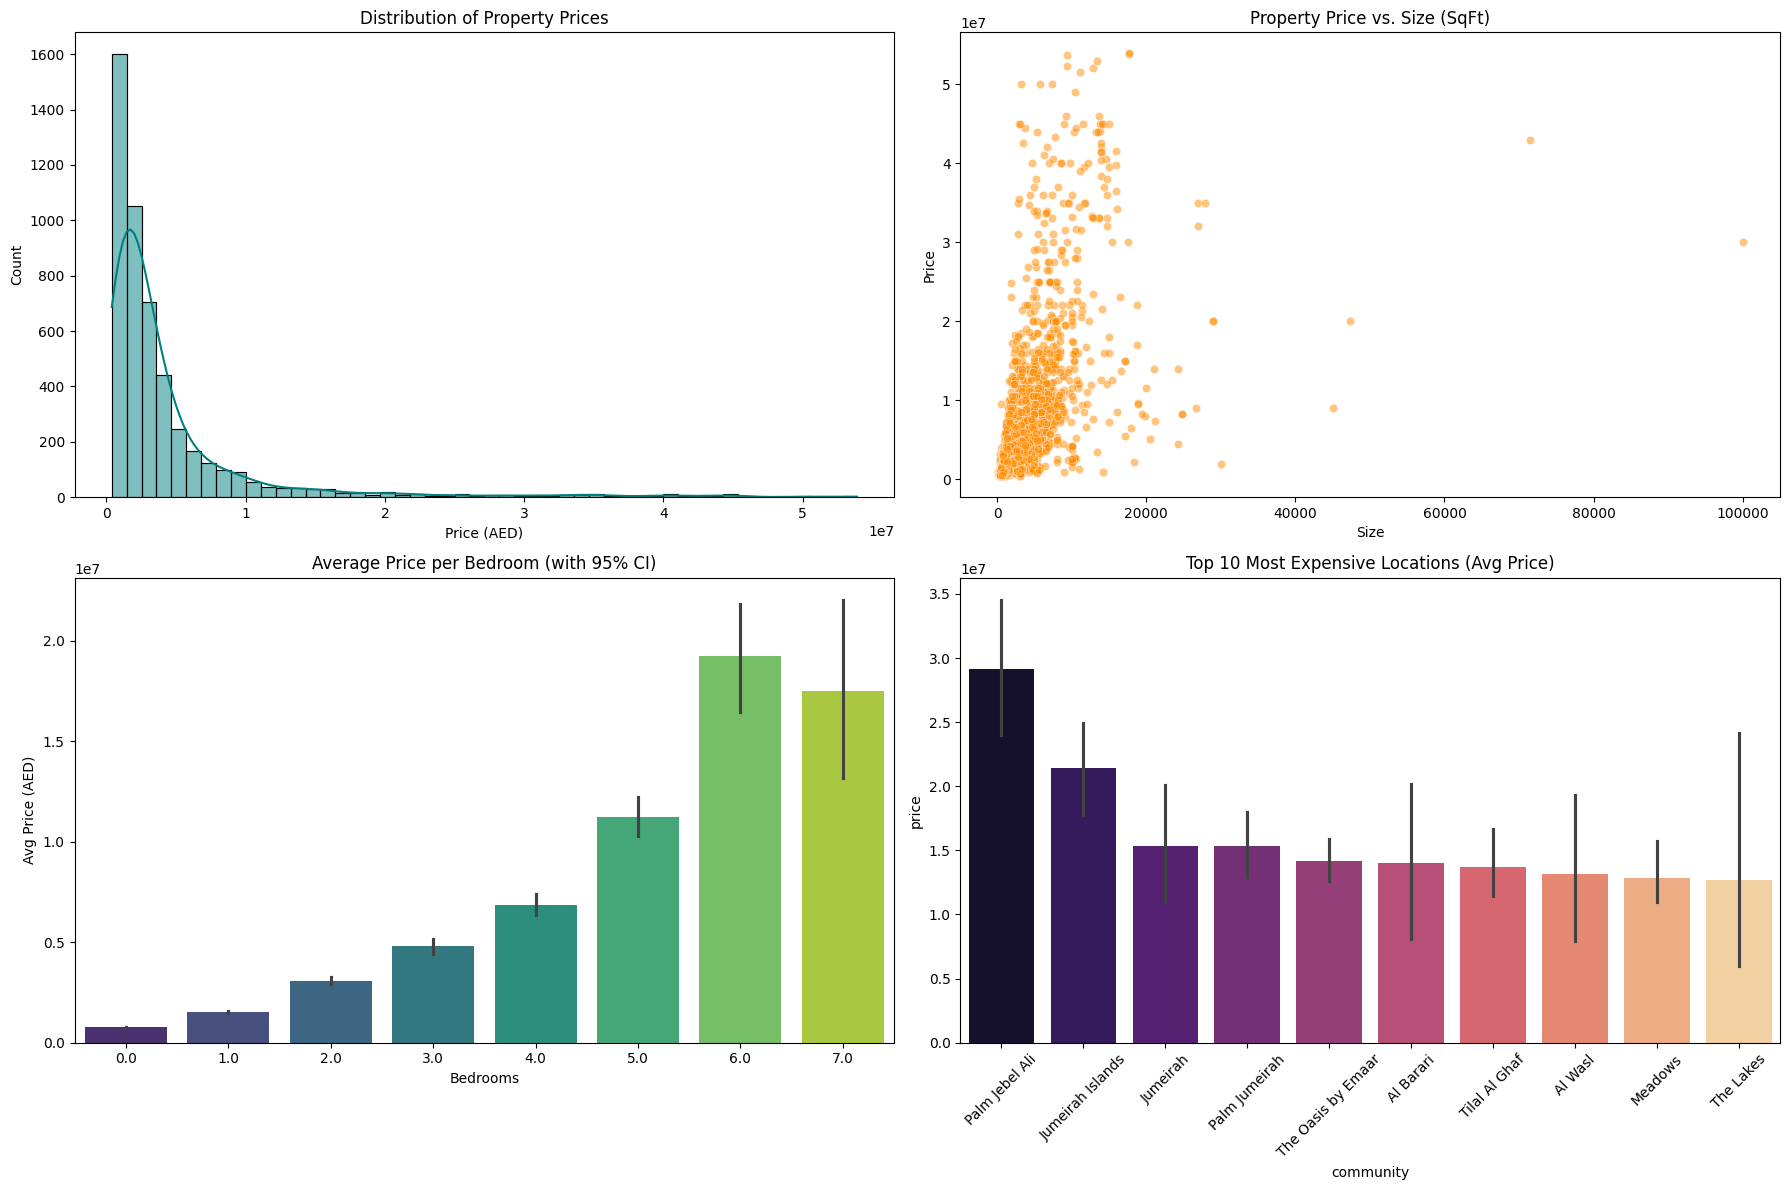

In [25]:
# without log transform
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Price Distribution
sns.histplot(df['price'], bins=50, kde=True, ax=axes[0, 0], color='teal')
axes[0, 0].set_title('Distribution of Property Prices')
axes[0, 0].set_xlabel('Price (AED)')

# 2. Price vs Size
sns.scatterplot(data=df, x='sizeMin_sqft', y='price', alpha=0.5, ax=axes[0, 1], color='darkorange')
axes[0, 1].set_title('Property Price vs. Size (SqFt)')
axes[0, 1].set_xlabel('Size')
axes[0, 1].set_ylabel('Price')

# 3. Avg Price by Bedrooms with Confidence Interval
sns.barplot(data=df, x='bedrooms', y='price', ax=axes[1,0], palette='viridis', errorbar='ci')
axes[1,0].set_title('Average Price per Bedroom (with 95% CI)')
axes[1,0].set_xlabel('Bedrooms')
axes[1,0].set_ylabel('Avg Price (AED)')

# 4. Top 10 Locations by Average Price
top_locations = df.groupby('community')['price'].mean().sort_values(ascending=False).head(10).index
sns.barplot(data=df[df['community'].isin(top_locations)], 
            x='community', y='price', order=top_locations, ax=axes[1, 1], palette='magma')
axes[1, 1].set_title('Top 10 Most Expensive Locations (Avg Price)')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

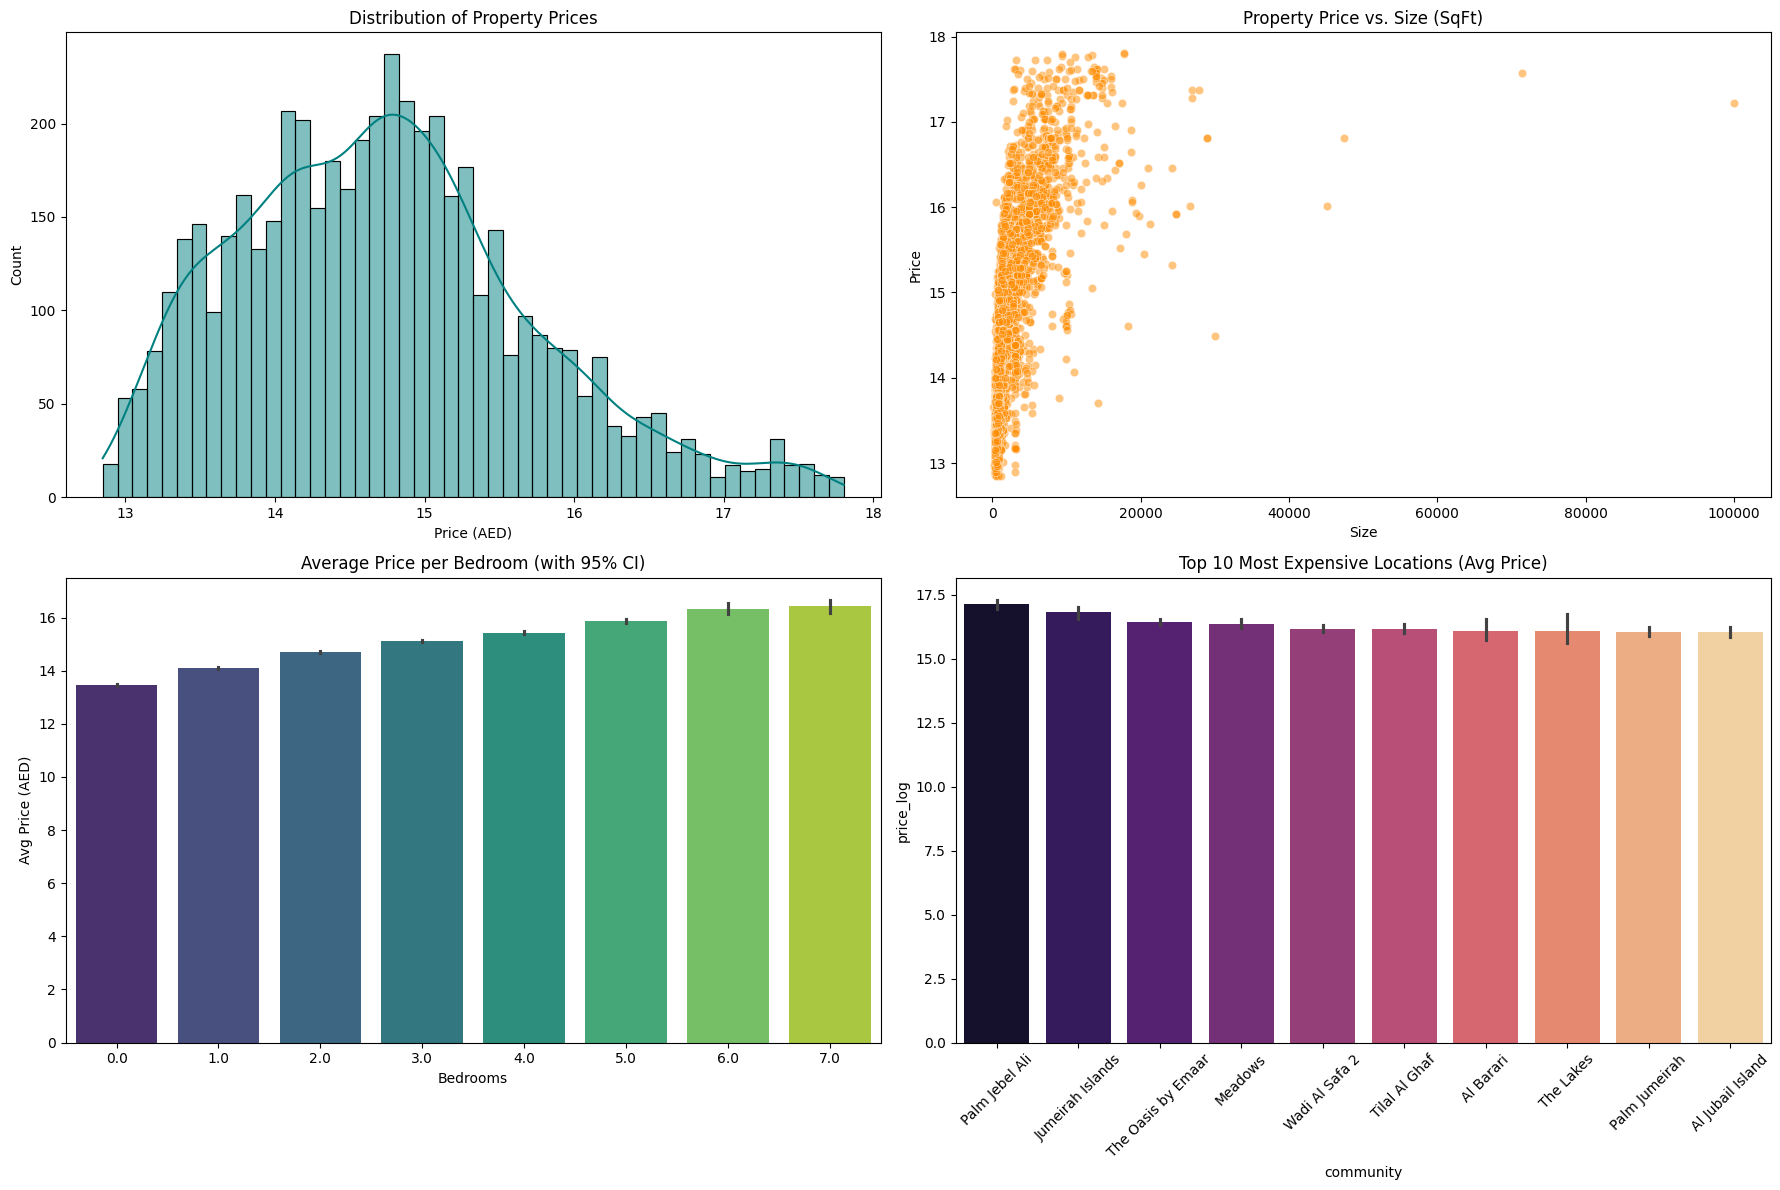

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Price Distribution
sns.histplot(df['price_log'], bins=50, kde=True, ax=axes[0, 0], color='teal')
axes[0, 0].set_title('Distribution of Property Prices')
axes[0, 0].set_xlabel('Price (AED)')

# 2. Price vs Size
sns.scatterplot(data=df, x='sizeMin_sqft', y='price_log', alpha=0.5, ax=axes[0, 1], color='darkorange')
axes[0, 1].set_title('Property Price vs. Size (SqFt)')
axes[0, 1].set_xlabel('Size')
axes[0, 1].set_ylabel('Price')

# 3. Avg Price by Bedrooms with Confidence Interval
sns.barplot(data=df, x='bedrooms', y='price_log', ax=axes[1,0], palette='viridis', errorbar='ci')
axes[1,0].set_title('Average Price per Bedroom (with 95% CI)')
axes[1,0].set_xlabel('Bedrooms')
axes[1,0].set_ylabel('Avg Price (AED)')

# 4. Top 10 Locations by Average Price
top_locations = df.groupby('community')['price_log'].mean().sort_values(ascending=False).head(10).index
sns.barplot(data=df[df['community'].isin(top_locations)], 
            x='community', y='price_log', order=top_locations, ax=axes[1, 1], palette='magma')
axes[1, 1].set_title('Top 10 Most Expensive Locations (Avg Price)')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

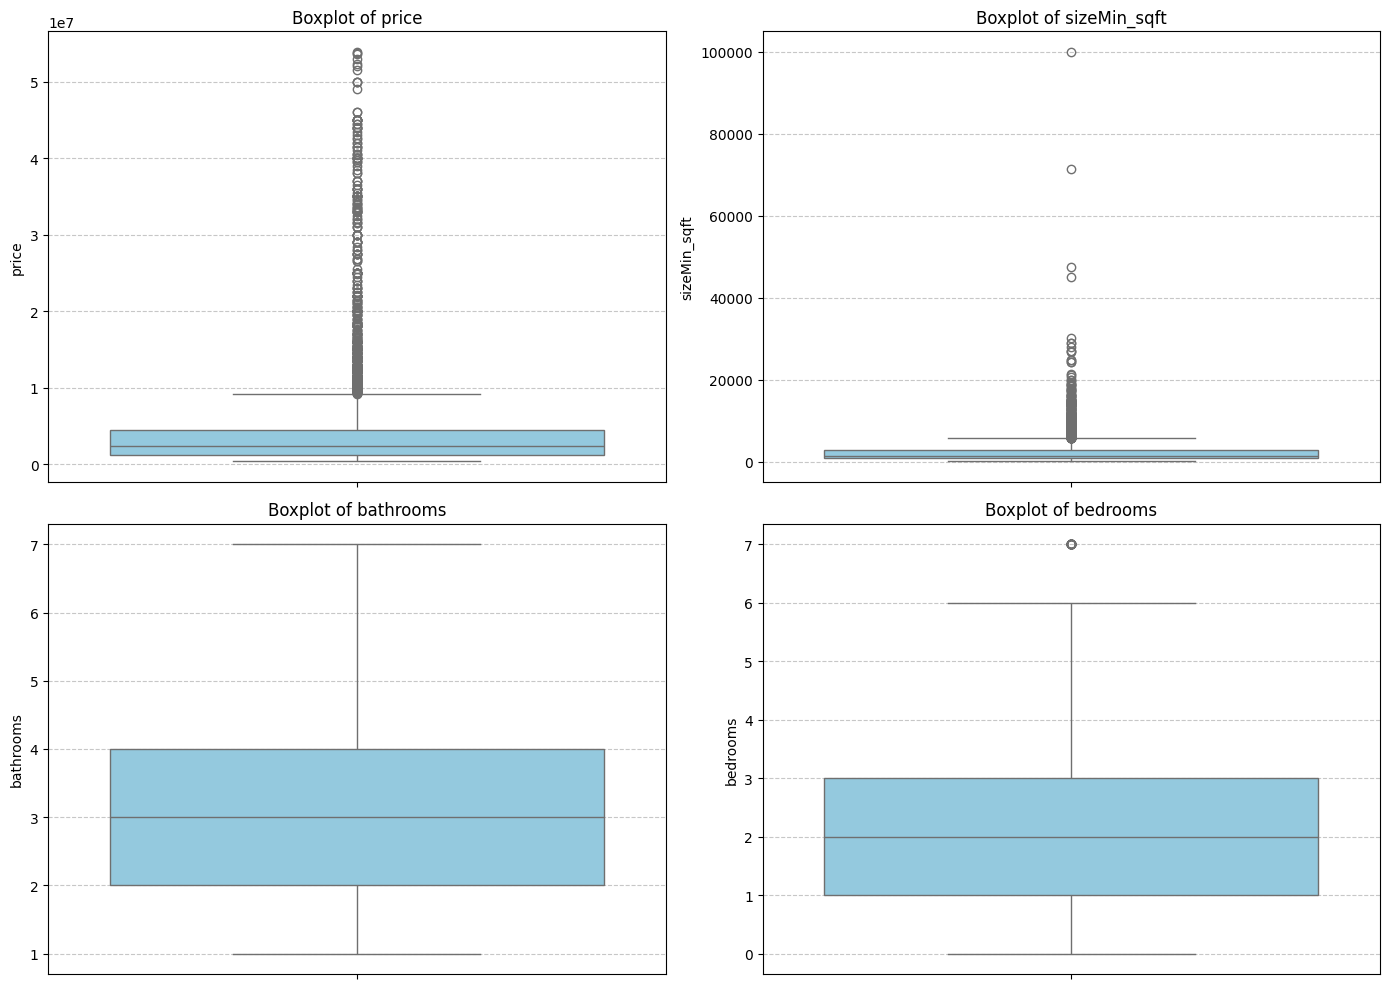

In [27]:
# price without using log transform
numeric_cols = ['price', 'sizeMin_sqft', 'bathrooms', 'bedrooms']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, y=col, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_ylabel(col)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

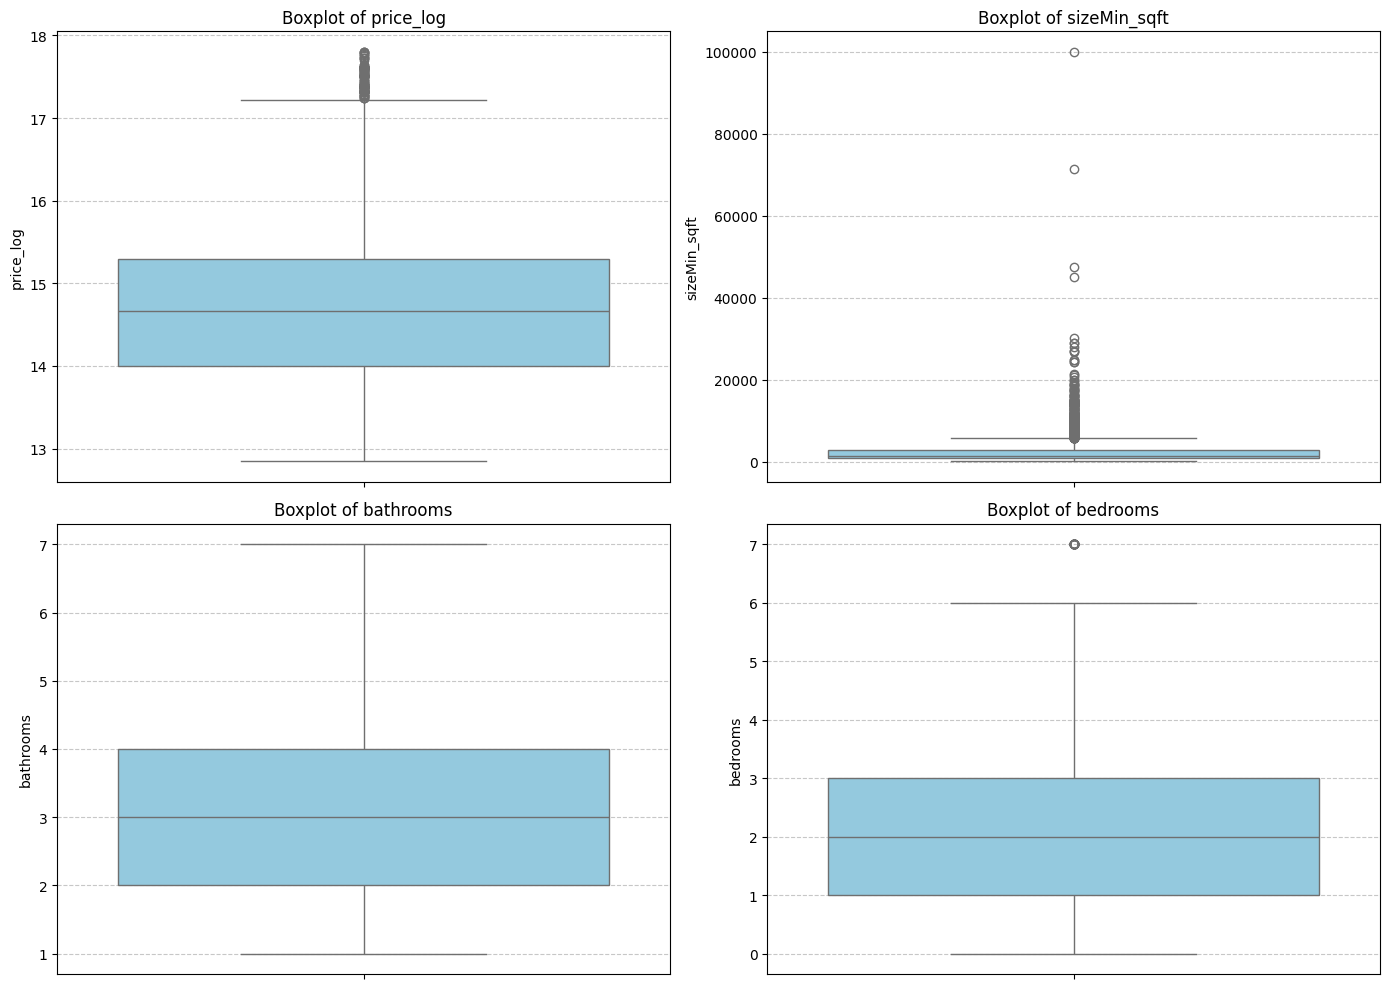

In [28]:
numeric_cols = ['price_log', 'sizeMin_sqft', 'bathrooms', 'bedrooms']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, y=col, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_ylabel(col)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

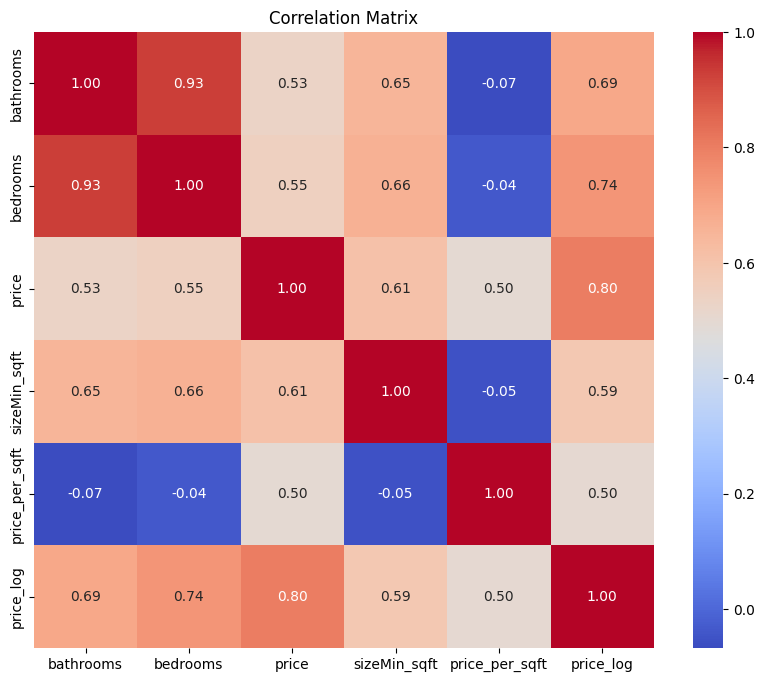

In [29]:
# Correlation matrix (numeric features)
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

# Custom Transformers for the Pipeline

In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4956 entries, 0 to 4955
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   bathrooms       4852 non-null   float64
 1   bedrooms        4851 non-null   float64
 2   price           4956 non-null   int64  
 3   sizeMin_sqft    4956 non-null   float64
 4   furnishing      4954 non-null   str    
 5   community       4956 non-null   str    
 6   price_per_sqft  4956 non-null   float64
 7   price_log       4956 non-null   float64
dtypes: float64(5), int64(1), str(2)
memory usage: 392.6 KB


In [31]:
X= df.drop(columns=['price', 'price_log', 'price_per_sqft'])
y= df['price_log']

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [33]:
numerical_features = ['sizeMin_sqft', 'bedrooms', 'bathrooms']
ordinal_features = ['furnishing'] 
target_features = ['community']

In [34]:
# 1. Numerical Pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler()) 
])

# 2. Ordinal Pipeline 
ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(
        categories=[['NO', 'PARTLY', 'YES']], 
        handle_unknown='use_encoded_value', 
        unknown_value=-1
    ))
])

# 3. Target Encoding Pipeline )
target_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), 
    ('target_encode', ce.TargetEncoder()) 
])

# 4. Combine all transformations
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),  
        ('cat_ord', ordinal_transformer, ordinal_features),
        ('cat_target', target_transformer, target_features)
    ],
    remainder='drop'
)

# Baseline Model

In [35]:
base_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])
base_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['sizeMin_sqft', 'bedrooms',
                                                   'bathrooms']),
                                                 ('cat_ord',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ordinal',
                                                                   OrdinalEncoder(categories=[['NO',
                                                                                               'PARTLY',
                                                                                               'YES']],
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['furnishing']),
                                                 ('cat_target',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('target_encode',
                                                                   TargetEncoder())]),
                                                  ['community'])])),
                ('regressor', LinearRegression())])

In [36]:
# 6. Wrap the model to handle the Log Transformation automatically (FIXED)
model = TransformedTargetRegressor(
    regressor=base_model,
    func=np.log1p,         # Applied to y_train during .fit()
    inverse_func=np.expm1  # Applied to predictions during .predict()
)
model.fit(X_train, y_train)

TransformedTargetRegressor(func=<ufunc 'log1p'>, inverse_func=<ufunc 'expm1'>,
                           regressor=Pipeline(steps=[('preprocessor',
                                                      ColumnTransformer(transformers=[('num',
                                                                                       Pipeline(steps=[('imputer',
                                                                                                        SimpleImputer(strategy='median')),
                                                                                                       ('scaler',
                                                                                                        RobustScaler())]),
                                                                                       ['sizeMin_sqft',
                                                                                        'bedrooms',
                                                                                        'bathrooms']),
                                                                                      ('cat_ord',
                                                                                       Pipeline(steps=[('imputer',
                                                                                                        SimpleImputer(strategy='most_frequent')),
                                                                                                       ('ordinal',
                                                                                                        OrdinalEncoder(categories=[['NO',
                                                                                                                                    'PARTLY',
                                                                                                                                    'YES']],
                                                                                                                       handle_unknown='use_encoded_value',
                                                                                                                       unknown_value=-1))]),
                                                                                       ['furnishing']),
                                                                                      ('cat_target',
                                                                                       Pipeline(steps=[('imputer',
                                                                                                        SimpleImputer(strategy='most_frequent')),
                                                                                                       ('target_encode',
                                                                                                        TargetEncoder())]),
                                                                                       ['community'])])),
                                                     ('regressor',
                                                      LinearRegression())]))

In [37]:
y_pred = base_model.predict(X_test) # Automatically outputs in standard scale!
y_true = y_test

MAE = mean_absolute_error(y_true, y_pred)
MSE = mean_squared_error(y_true, y_pred)
RMSE = np.sqrt(MSE)
R2 = r2_score(y_true, y_pred)

print(f"Mean Absolute Error: {MAE:.2f}")
print(f"Mean Squared Error: {MSE:.2f}")
print(f"Root Mean Squared Error: {RMSE:.2f}")
print(f"R-squared: {R2:.4f}")

Mean Absolute Error: 0.38
Mean Squared Error: 0.25
Root Mean Squared Error: 0.50
R-squared: 0.7457


In [38]:
xgb_core = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(
        n_estimators=800,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
            colsample_bytree=0.8,
            min_child_weight=5,
            reg_alpha=0.1,
            reg_lambda=1.0,
            random_state=42,
            n_jobs=-1,
        )),
])

In [39]:
xgb_model = TransformedTargetRegressor(regressor=xgb_core, func=np.log1p, inverse_func=np.expm1)
xgb_model.fit(X_train, y_train)

TransformedTargetRegressor(func=<ufunc 'log1p'>, inverse_func=<ufunc 'expm1'>,
                           regressor=Pipeline(steps=[('preprocessor',
                                                      ColumnTransformer(transformers=[('num',
                                                                                       Pipeline(steps=[('imputer',
                                                                                                        SimpleImputer(strategy='median')),
                                                                                                       ('scaler',
                                                                                                        RobustScaler())]),
                                                                                       ['sizeMin_sqft',
                                                                                        'bedrooms',
                                                                                        'bathrooms']),
                                                                                      ('cat_ord',
                                                                                       Pipeline(steps=[('imputer',
                                                                                                        SimpleImputer(strategy='mo...
                                                                   feature_weights=None,
                                                                   gamma=None,
                                                                   grow_policy=None,
                                                                   importance_type=None,
                                                                   interaction_constraints=None,
                                                                   learning_rate=0.05,
                                                                   max_bin=None,
                                                                   max_cat_threshold=None,
                                                                   max_cat_to_onehot=None,
                                                                   max_delta_step=None,
                                                                   max_depth=5,
                                                                   max_leaves=None,
                                                                   min_child_weight=5,
                                                                   missing=nan,
                                                                   monotone_constraints=None,
                                                                   multi_strategy=None,
                                                                   n_estimators=800,
                                                                   n_jobs=-1,
                                                                   num_parallel_tree=None, ...))]))

In [40]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    xgb_model, X_train, y_train,
    cv=5, scoring='r2', n_jobs=-1
    )
print(f"\n5-Fold CV R² (train): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


5-Fold CV R² (train): 0.9022 ± 0.0079


In [41]:
y_pred_xgb = xgb_model.predict(X_test)
MAE_xgb = mean_absolute_error(y_test, y_pred_xgb)
MAE_percent = MAE_xgb / y_test.mean() * 100
MSE_xgb = mean_squared_error(y_test, y_pred_xgb)
RMSE_xgb = np.sqrt(MSE_xgb)
R2_xgb = r2_score(y_test, y_pred_xgb)
print(f"XGBoost Mean Absolute Error: {MAE_xgb:.2f}")
print(f"XGBoost Mean Absolute Error (% of mean price): {MAE_percent:.2f}%")
print(f"XGBoost Mean Squared Error: {MSE_xgb:.2f}")
print(f"XGBoost Root Mean Squared Error: {RMSE_xgb:.2f}")
print(f"XGBoost R-squared: {R2_xgb:.4f}")

XGBoost Mean Absolute Error: 0.21
XGBoost Mean Absolute Error (% of mean price): 1.41%
XGBoost Mean Squared Error: 0.09
XGBoost Root Mean Squared Error: 0.30
XGBoost R-squared: 0.9100


In [42]:
rf_core = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42, n_estimators=800, max_depth=10, n_jobs=-1))
])

In [43]:
rf_model = TransformedTargetRegressor(regressor=rf_core, func=np.log1p, inverse_func=np.expm1)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

In [44]:
MAE_rf = mean_absolute_error(y_true, y_pred_rf)
MSE_rf = mean_squared_error(y_true, y_pred_rf)
RMSE_rf = np.sqrt(MSE_rf)
R2_rf = r2_score(y_true, y_pred_rf)
print(f"Random Forest Mean Absolute Error: {MAE_rf:.2f}")
print(f"Random Forest Mean Squared Error: {MSE_rf:.2f}")
print(f"Random Forest Root Mean Squared Error: {RMSE_rf:.2f}")
print(f"Random Forest R-squared: {R2_rf:.4f}")

Random Forest Mean Absolute Error: 0.23
Random Forest Mean Squared Error: 0.11
Random Forest Root Mean Squared Error: 0.33
Random Forest R-squared: 0.8896


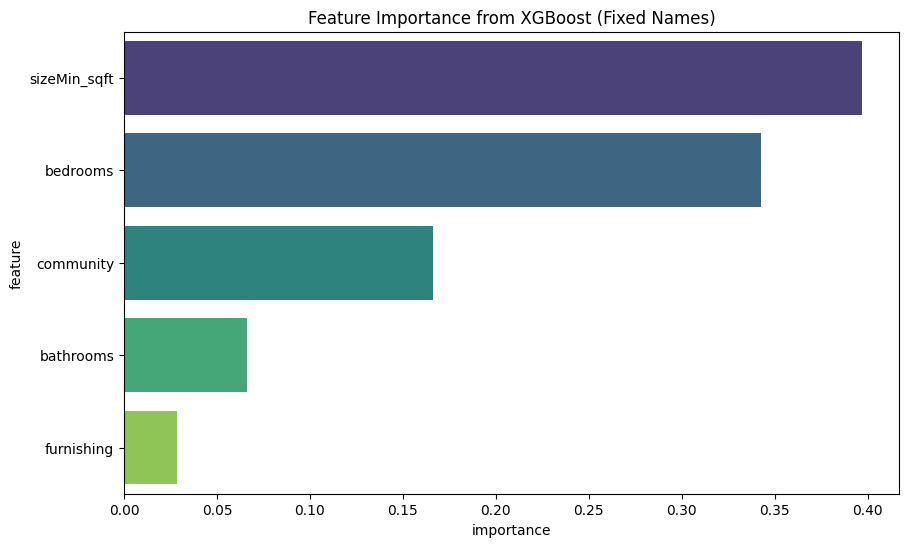

In [45]:
# Feature Importance from XGBoost
trained_xgb = xgb_model.regressor_.named_steps['regressor']
importances = trained_xgb.feature_importances_

raw_names = xgb_model.regressor_.named_steps['preprocessor'].get_feature_names_out()

clean_names = []
for name in raw_names:
    clean_name = name.split("__")[-1]
    if clean_name == "0" and "cat_target" in name:
        clean_names.append("community")
    elif clean_name == "0" and "cat_ord" in name:
        clean_names.append("furnishing")
    else:
        clean_names.append(clean_name)

feature_importance_df = pd.DataFrame({'feature': clean_names, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df, x='importance', y='feature', palette='viridis')
plt.title('Feature Importance from XGBoost (Fixed Names)')
plt.show()

In [46]:
# Save model
joblib.dump(xgb_model, 'xgb_real_estate_model.pkl')
xgb_model = joblib.load('xgb_real_estate_model.pkl')

# Classifier

In [47]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [48]:
X_train['area_per_bedroom'] = X_train['sizeMin_sqft'] / (X_train['bedrooms'] + 1)
X_test['area_per_bedroom'] = X_test['sizeMin_sqft'] / (X_test['bedrooms'] + 1)

In [49]:
y_train_pred_price = xgb_model.predict(X_train)
train_residuals = y_train.values - y_train_pred_price

In [50]:
threshold_overpriced = np.percentile(train_residuals, 75)
y_train_clf = (train_residuals > threshold_overpriced).astype(int)

In [51]:
y_test_pred_price = xgb_model.predict(X_test)
test_residuals = y_test.values - y_test_pred_price
y_test_clf = (test_residuals > threshold_overpriced).astype(int)

In [52]:
ratio = float(np.sum(y_train_clf == 0)) / np.sum(y_train_clf == 1)

clf_xgb_tuned = Pipeline(steps=[
    ('preprocessor', preprocessor), 
    ('classifier', XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        scale_pos_weight=ratio, # هذا المعامل أقوى من SMOTE في حالة البيانات المزعجة
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ))
])
clf_xgb_tuned.fit(X_train, y_train_clf)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['sizeMin_sqft', 'bedrooms',
                                                   'bathrooms']),
                                                 ('cat_ord',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ordinal',
                                                                   OrdinalEncoder(categories=[['NO',
                                                                                               'PARTLY',
                                                                                               'YES']],
                                                                                  handle_un...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=-1,
                               num_parallel_tree=None, ...))])

In [53]:
y_clf_proba = clf_xgb_tuned.predict_proba(X_test)[:, 1]
custom_threshold = 0.40  
y_custom_pred = (y_clf_proba >= custom_threshold).astype(int)

Pricing Fairness Classifier: Handling Imbalance & The Precision-Recall Tradeoff
The Problem & SMOTE's Failure: We built a classifier to flag "Overpriced" vs. "Fair" properties. Initially, we used SMOTE to handle class imbalance, but it failed (Recall dropped to 0.31). SMOTE generated synthetic noise in overlapping regions where fair and overpriced properties share identical features (like size and location) but differ in unrecorded aspects (like view or finishing).

The Solution: We replaced SMOTE with Cost-Sensitive Learning using XGBoost's scale_pos_weight to heavily penalize errors on the minority class. Additionally, we applied Threshold Tuning, lowering the decision threshold to 0.40 to make the model more sensitive.

The Result & Business Value: The Recall for overpriced properties surged to 0.76, at the cost of Precision dropping to 0.39. This Precision-Recall Tradeoff was an intentional business choice to build a "Buyer-Safe" system. We optimized for Recall to prevent buyers from losing money on bad deals (minimizing False Negatives), accepting that the model will sometimes issue overly cautious warnings (False Positives).

In [54]:
print(classification_report(y_test_clf, y_custom_pred, target_names=["Fair/Good Deal", "Overpriced"]))

                precision    recall  f1-score   support

Fair/Good Deal       0.84      0.52      0.64       706
    Overpriced       0.39      0.76      0.51       286

      accuracy                           0.59       992
     macro avg       0.62      0.64      0.58       992
  weighted avg       0.71      0.59      0.61       992



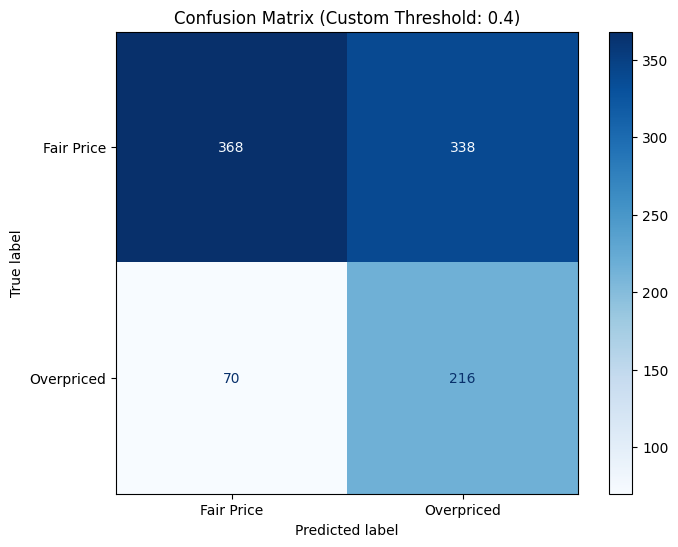

In [55]:
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test_clf, y_custom_pred, 
                                        display_labels=["Fair Price", "Overpriced"], 
                                        cmap='Blues', ax=ax)
plt.title(f"Confusion Matrix (Custom Threshold: {custom_threshold})")
plt.show()

In [56]:
# Save classifier
joblib.dump(clf_xgb_tuned, "price_classifier_tuned.pkl")

optimal_threshold = 0.40
joblib.dump(optimal_threshold, "optimal_threshold.pkl")

['optimal_threshold.pkl']

# Recommendation System 

**Content-based**: recommend properties similar to those the user viewed (based on bedrooms, bathrooms, size, community, price range).



**Using Cosine Similarity**  to recommend properties with similar attributes (size, location, rooms, and price).

In [57]:
# Fit on X_train and y_train ONLY to prevent data leakage
preprocessor.fit(X_train, y_train)
# Transform the entire dataset (X) so we can search across all available properties
X_matrix = preprocessor.transform(X)

In [58]:
# Scale Price and Merge into the Matrix
price_scaler = RobustScaler()
price_scaled = price_scaler.fit_transform(df[['price']])

In [59]:
# Stack the features matrix and the scaled price array together horizontally
recommendation_matrix = np.hstack((X_matrix, price_scaled))

In [60]:
# 4. Fit the Nearest Neighbors Model
# metric='cosine' looks at the angle between data points (perfect for feature similarity)
# n_neighbors=6 because the closest match is always the property itself (we will filter it out)
recommender = NearestNeighbors(n_neighbors=6, metric='cosine', algorithm='brute', n_jobs=-1)
recommender.fit(recommendation_matrix)

NearestNeighbors(algorithm='brute', metric='cosine', n_jobs=-1, n_neighbors=6)

In [61]:
# 5. Recommendation Function
def get_similar_properties(property_index, df, model, matrix):
    """
    Given a property's index, returns the top 5 most similar properties.
    """
    # Find the nearest neighbors for the specified property
    # We reshape the single row to a 2D array as required by sklearn
    distances, indices = model.kneighbors(matrix[property_index].reshape(1, -1))
    
    # The first index is the property itself, so we take [1:] to get the 5 recommendations
    similar_indices = indices[0][1:]
    
    # Convert cosine distance to a similarity score percentage (1.0 is a perfect match)
    similarity_scores = 1 - distances[0][1:] 
    
    # Display only key columns for readability
    display_cols = ['price', 'bedrooms', 'bathrooms', 'sizeMin_sqft', 'community', 'furnishing']
    display(df.iloc[[property_index]][display_cols])
    
    # Prepare the recommendations dataframe
    recommendations = df.iloc[similar_indices].copy()
    recommendations['Match_Score'] = [f"{round(s * 100, 1)}%" for s in similarity_scores]
    
    # Rearrange columns to put the Match_Score and price at the beginning
    final_cols = ['Match_Score', 'price', 'community', 'bedrooms', 'bathrooms', 'sizeMin_sqft', 'furnishing']
    recommendations = recommendations[final_cols]
    
    print("\nTOP 5 RECOMMENDED PROPERTIES:")
    display(recommendations)
    
    return recommendations

In [62]:
# --- Test the Recommender ---
# Let's get recommendations for the very first property in our dataset (Index 0)
recommended_df = get_similar_properties(
    property_index=0, 
    df=df, 
    model=recommender, 
    matrix=recommendation_matrix
)

,price,bedrooms,bathrooms,sizeMin_sqft,community,furnishing
0,2500000,2.0,3.0,1323.0,Business Bay,NO



TOP 5 RECOMMENDED PROPERTIES:


,Match_Score,price,community,bedrooms,bathrooms,sizeMin_sqft,furnishing
2259,100.0%,2500000,Jumeirah Lake Towers,2.0,3.0,1337.0,NO
980,100.0%,2500000,Dubai Marina,2.0,3.0,1302.0,NO
2415,100.0%,2500000,Downtown Dubai,2.0,3.0,1348.0,NO
1255,100.0%,2490000,Expo City,2.0,3.0,1377.0,NO
4514,100.0%,2428900,DIFC,2.0,3.0,1276.0,NO


In [63]:
# 1. Save the preprocessor (to transform any new data in the exact same way)
joblib.dump(preprocessor, 'preprocessor.pkl')

# 2. Save the price scaler (to maintain the price weight we applied)
joblib.dump(price_scaler, 'price_scaler.pkl')

# 3. Save the recommendation model itself
joblib.dump(recommender, 'recommender_model.pkl')

# 4. Save the recommendation matrix (so we can search directly within it later)
joblib.dump(recommendation_matrix, 'recommendation_matrix.pkl')

# 5. Save the original DataFrame (to display property details to the user)
df.to_pickle('properties_data.pkl')